In [9]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

all_data = pd.read_csv("C:\\Users\\ASUS\\Documents\\Prac\homework_1\\forest_dataset.csv")
all_data.head()

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values


clf = KNeighborsClassifier(n_neighbors=1, weights=None, metric="euclidean")
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
accuracy_score(test_labels, y_pred)

<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14312\3890579322.py:7: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  all_data = pd.read_csv("C:\\Users\\ASUS\\Documents\\Prac\homework_1\\forest_dataset.csv")


0.783

In [10]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)

clf_grid.fit(train_feature_matrix, train_labels)

print(f"Лучшие параметры: {clf_grid.best_params_}")
print(f"Лучшая кросс-валидационная точность: {clf_grid.best_score_:.3f}")

# Оценка на тестовой выборке
best_clf = clf_grid.best_estimator_
y_pred = best_clf.predict(test_feature_matrix)
test_accuracy = accuracy_score(test_labels, y_pred)
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")


Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Лучшая кросс-валидационная точность: 0.768
Точность на тестовой выборке: 0.784


In [11]:
optimal_clf = clf_grid.best_estimator_

optimal_clf.fit(train_feature_matrix, train_labels)

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

print(f"Форма массива вероятностей: {pred_prob.shape}")
print(f"Вероятности для первых 5 тестовых объектов:\n{pred_prob[:5]}")
print(f"Предсказанные классы: {optimal_clf.predict(test_feature_matrix)[:5]}")
print(f"Максимальные вероятности: {pred_prob.max(axis=1)[:5]}")

Форма массива вероятностей: (2000, 7)
Вероятности для первых 5 тестовых объектов:
[[0.         1.         0.         0.         0.         0.
  0.        ]
 [0.73117861 0.26882139 0.         0.         0.         0.
  0.        ]
 [0.27814042 0.72185958 0.         0.         0.         0.
  0.        ]
 [1.         0.         0.         0.         0.         0.
  0.        ]
 [0.         1.         0.         0.         0.         0.
  0.        ]]
Предсказанные классы: [2 1 2 1 2]
Максимальные вероятности: [1.         0.73117861 0.72185958 1.         1.        ]


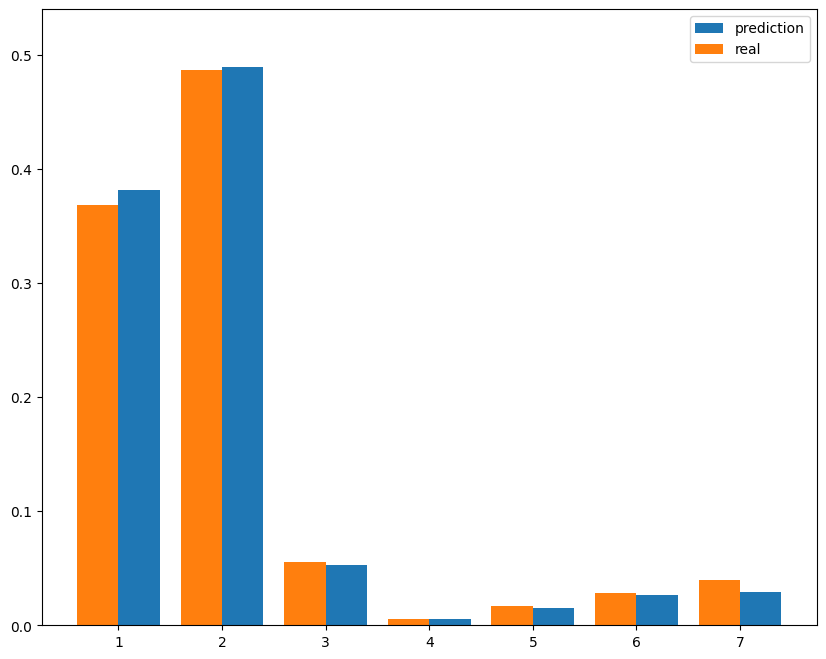

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Логистическая регрессия с масштабированием (важно для сходимости)
lr_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
)

lr_clf.fit(train_feature_matrix, train_labels)
lr_pred = lr_clf.predict(test_feature_matrix)
lr_accuracy = accuracy_score(test_labels, lr_pred)

print(f"Точность логистической регрессии: {lr_accuracy:.3f}")
print(f"Точность kNN: {test_accuracy:.3f}")
print(f"Разница: {(test_accuracy - lr_accuracy):.3f}")

Точность логистической регрессии: 0.620
Точность kNN: 0.784
Разница: 0.164


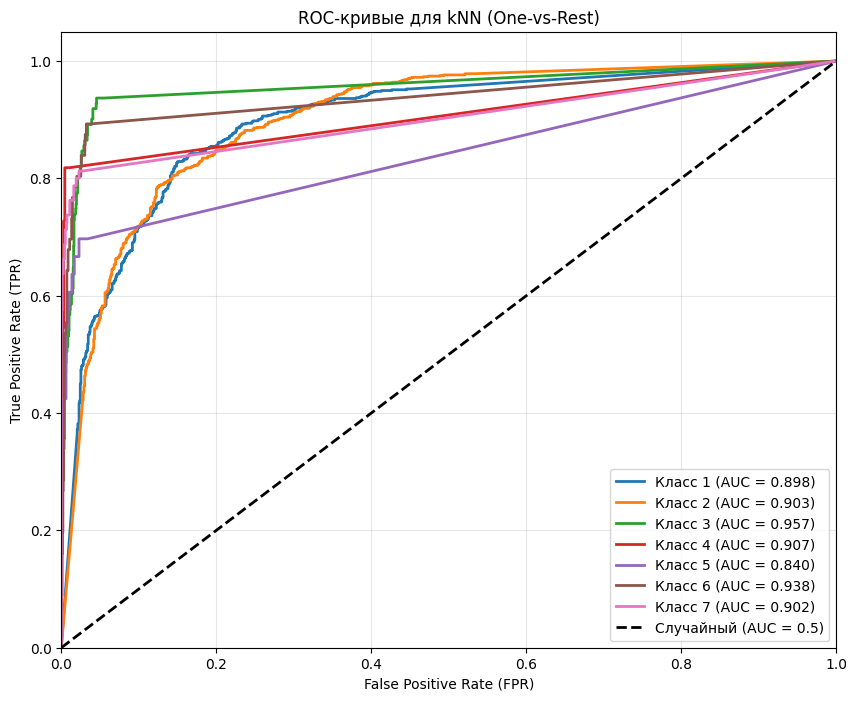

Средний AUC-ROC (macro): 0.906
Средний AUC-ROC (weighted): 0.904
AUC-ROC по классам: {0: 0.8980612788937811, 1: 0.9029327379659772, 2: 0.95698424734952, 3: 0.9067142008318481, 4: 0.8401811711420253, 5: 0.9375964506172839, 6: 0.9019466145833334}


: 

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Бинаризуем метки для многоклассовой ROC (One-vs-Rest)
n_classes = len(np.unique(labels))
test_labels_bin = label_binarize(test_labels, classes=range(1, n_classes + 1))

# Получаем вероятности для каждого класса
pred_prob = best_clf.predict_proba(test_feature_matrix)

# Строим ROC-кривую для каждого класса
plt.figure(figsize=(10, 8))

roc_auc = {}
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Класс {i+1} (AUC = {roc_auc[i]:.3f})')

# Диагональная линия (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые для kNN (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Средний AUC (macro и weighted)
from sklearn.metrics import roc_auc_score

# Macro-average
macro_auc = roc_auc_score(test_labels_bin, pred_prob, average='macro', multi_class='ovr')
# Weighted-average
weighted_auc = roc_auc_score(test_labels_bin, pred_prob, average='weighted', multi_class='ovr')

print(f"Средний AUC-ROC (macro): {macro_auc:.3f}")
print(f"Средний AUC-ROC (weighted): {weighted_auc:.3f}")
print(f"AUC-ROC по классам: {roc_auc}")

Выводы:
a. Какая модель лучше и почему?
kNN лучше в данном случае, потому что:

1. Выше точность (0.784 против 0.620 у LR)
2. Данные могут иметь нелинейные зависимости, которые kNN лучше улавливает
3. Признаки могут быть сложно разделимы линейной границей

b. Плюсы и минусы метода k ближайших соседей

Плюсы:
1. Простота реализации и понимания — интуитивно понятный алгоритм
2. Не делает предположений о распределении данных (непараметрический)
3. Хорошо работает с многоклассовой классификацией естественным образом
4. Может улавливать сложные нелинейные зависимости

Минусы:
1. Вычислительная сложность на больших данных — O(n) на предсказание
2. Чувствительность к масштабу признаков (нужна нормализация)
3. Проклятие размерности — при большом количестве признаков эффективность падает
5. Требует хранения всей обучающей выборки в памяти
6. Чувствительность к шуму и выбросам